In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

In [11]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [12]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [13]:
design_matrix.shape

(680, 71)

In [14]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance", 
]

In [15]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    (design_matrix['sofa_score_increase_day2'] > 1) & (design_matrix['sofa_score_increase_day3'] > 1), 1, 0
)
design_matrix_test['future_deterioration'] = np.where(
    (design_matrix_test['sofa_score_increase_day2'] > 1) & (design_matrix_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [16]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [17]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    bootstrap_replace=False,
    bootstrap_fraction=0.9,
    bootstrap_iterations=1000
)
df_estimator.fit(training_data, features=clinical_columns)

# 30-day Mortality

In [18]:
testing_data['Mortality 30 Day Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="survival_30_day",
    bootstrap=True
)

In [19]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [20]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['survival_30_day'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Mortality (30-Day)": actual_mort,
            "Estimated Mortality (30-Day)": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [21]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [22]:
bootstrap_counts.to_csv(
    "mortality_df.tsv",
    sep="\t",
    index=False
)

In [23]:
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [24]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Mortality (30-Day)']], bootstrap_counts[['Actual Mortality (30-Day)']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Mortality (30-Day)']].values.ravel(), bootstrap_counts[['Actual Mortality (30-Day)']].values.ravel())
linregress_results


LinregressResult(slope=1.4090599747418278, intercept=-0.007163838012548884, rvalue=0.8801762616106802, pvalue=0.0, stderr=0.009301166980044658, intercept_stderr=0.0032105964432474514)

In [26]:
rsquared = linregress_results.rvalue ** 2

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Mortality (30-Day)']].values.ravel()

In [28]:

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts['Estimated Mortality (30-Day)'].unique()

In [29]:
predictions = pd.DataFrame(
    {
        "x": bootstrap_counts['Estimated Mortality (30-Day)'].unique(),
        "y": predictions
    }
)

In [30]:
predictions = predictions.sort_values("x")

In [31]:
predictions['x'] = predictions['x'].astype("str")

In [32]:
bootstrap_counts['Estimated Mortality (30-Day)'] = bootstrap_counts['Estimated Mortality (30-Day)'].astype(str)

In [33]:
bootstrap_counts['Estimated Mortality (30-Day)'] = bootstrap_counts['Estimated Mortality (30-Day)'].str[:3]

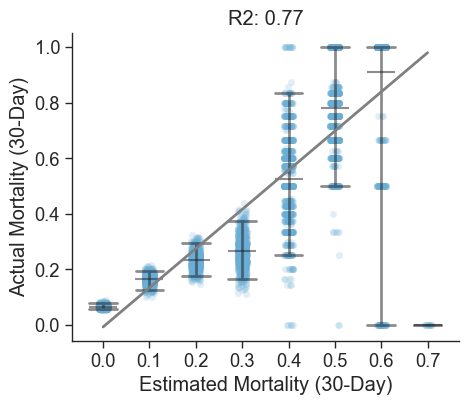

In [34]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)


import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.pointplot(
    data=bootstrap_counts,
    x="Estimated Mortality (30-Day)",
    y="Actual Mortality (30-Day)",
    hue="Estimated Mortality (30-Day)",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=bootstrap_counts,
    x="Estimated Mortality (30-Day)",
    y="Actual Mortality (30-Day)",
    #hue="Label",
    ax=ax,
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

plt.plot(
    predictions["x"],
    predictions["y"],
    lw=2,
    color="gray",
)

ax.set_title(
    f"R2: {rsquared:.2f}"
)

fig.set_size_inches(5, 4)


In [35]:
estimated_mort['Predicted Fit'] = linreg.predict(estimated_mort[['Estimated Mortality (30-Day)']])

In [36]:
fig.savefig("mortality.pdf", dpi=300, bbox_inches="tight")

In [37]:
combined_results.to_csv(
    "design_matrix_test_mortality_risk.tsv",
    sep="\t"
)

# Deterioration

In [38]:
testing_data['Future Deterioration Mean'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="future_deterioration",
    bootstrap=True
)

In [39]:
combined_results = pd.concat([testing_data.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

In [40]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['future_deterioration'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Deterioration": actual_mort,
            "Estimated Deterioration": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [41]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [42]:
bootstrap_counts.to_csv(
    "deterioration_df.tsv",
    sep="\t",
    index=False
)

In [43]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Deterioration']], bootstrap_counts[['Actual Deterioration']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Deterioration']].values.ravel(), bootstrap_counts[['Actual Deterioration']].values.ravel())
linregress_results


LinregressResult(slope=0.8644885972092047, intercept=0.10473453282353057, rvalue=0.9319336566788693, pvalue=0.0, stderr=0.003481977448355152, intercept_stderr=0.0017340220204457042)

In [45]:
rsquared = linregress_results.rvalue ** 2

In [46]:

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts['Estimated Deterioration'].unique()

In [47]:
predictions = pd.DataFrame(
    {
        "x": bootstrap_counts['Estimated Deterioration'].unique(),
        "y": predictions
    }
)

In [48]:
predictions = predictions.sort_values("x")

In [49]:
predictions['x'] = predictions['x'].astype("str")

In [50]:
bootstrap_counts['Estimated Deterioration'] = bootstrap_counts['Estimated Deterioration'].astype(str)

In [51]:
bootstrap_counts['Estimated Deterioration'] = bootstrap_counts['Estimated Deterioration'].str[:3]

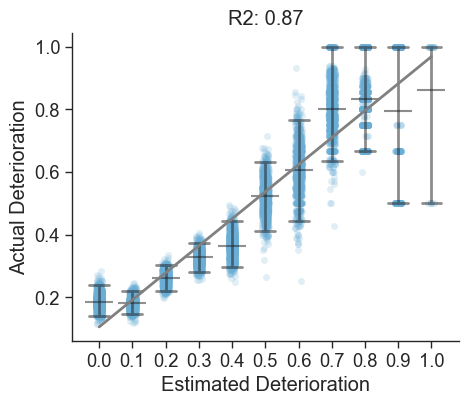

In [52]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.pointplot(
    data=bootstrap_counts,
    x="Estimated Deterioration",
    y="Actual Deterioration",
    hue="Estimated Deterioration",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=bootstrap_counts,
    x="Estimated Deterioration",
    y="Actual Deterioration",
    #hue="Label",
    ax=ax,
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

ax.plot(
    predictions["x"],
    predictions["y"],
    lw=2,
    color="gray",
)


ax.set_title(
    f"R2: {rsquared:.2f}"
)

fig.set_size_inches(5, 4)


In [53]:
fig.savefig("deterioration.pdf", dpi=300, bbox_inches="tight")

In [54]:
combined_results.to_csv(
    "design_matrix_test_deterioration.tsv",
    sep="\t"
)

# Sepsis

In [55]:
testing_data['Sepsis Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock",
    bootstrap=True
)

In [56]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [57]:

bootstrap_counts = []

for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['sepsis_or_septic_shock'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Sepsis": actual_mort,
            "Estimated Sepsis": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [58]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [59]:
bootstrap_counts.to_csv(
    "sepsis_df.tsv",
    sep="\t",
    index=False
)

In [60]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Sepsis']], bootstrap_counts[['Actual Sepsis']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Sepsis']].values.ravel(), bootstrap_counts[['Actual Sepsis']].values.ravel())
linregress_results


LinregressResult(slope=0.8550055912786022, intercept=0.10168861183310451, rvalue=0.9444508023094995, pvalue=0.0, stderr=0.0029163748754598416, intercept_stderr=0.0017735285969112976)

In [62]:
rsquared = linregress_results.rvalue ** 2

In [63]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Sepsis']].values.ravel()

In [64]:

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts['Estimated Sepsis'].unique()

In [65]:
predictions = pd.DataFrame(
    {
        "x": bootstrap_counts['Estimated Sepsis'].unique(),
        "y": predictions
    }
)

In [66]:
predictions = predictions.sort_values("x")

In [67]:
predictions['x'] = predictions['x'].astype("str")

In [68]:
bootstrap_counts['Estimated Sepsis'] = bootstrap_counts['Estimated Sepsis'].astype(str)

In [69]:
bootstrap_counts['Estimated Sepsis'] = bootstrap_counts['Estimated Sepsis'].str[:3]

In [70]:
bootstrap_counts['Estimated Sepsis']

0    0.0
1    0.1
2    0.2
3    0.3
4    0.4
    ... 
5    0.6
6    0.7
7    0.8
8    0.9
9    1.0
Name: Estimated Sepsis, Length: 10410, dtype: object

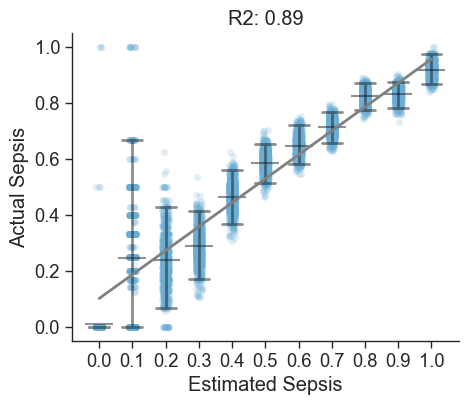

In [71]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.pointplot(
    data=bootstrap_counts,
    x="Estimated Sepsis",
    y="Actual Sepsis",
    hue="Estimated Sepsis",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=bootstrap_counts,
    x="Estimated Sepsis",
    y="Actual Sepsis",
    #hue="Label",
    ax=ax,
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

ax.plot(
    predictions["x"],
    predictions["y"],
    lw=2,
    color="gray",
)


ax.set_title(
    f"R2: {rsquared:.2f}"
)

fig.set_size_inches(5, 4)


In [72]:
combined_results.to_csv(
    "design_matrix_test_sepsis_risk.tsv",
    sep="\t",
    index=False
)

In [73]:
fig.savefig("sepsis_diagnosis.pdf", dpi=300, bbox_inches="tight")

# Infection

In [74]:
testing_data['Infection Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="verified_infection",
    bootstrap=True
)

In [75]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [76]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['verified_infection'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Infection": actual_mort,
            "Estimated Infection": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [77]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [78]:
bootstrap_counts.to_csv(
    "infection_df.tsv",
    sep="\t",
    index=False
)

In [79]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Infection']], bootstrap_counts[['Actual Infection']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Infection']].values.ravel(), bootstrap_counts[['Actual Infection']].values.ravel())
linregress_results


LinregressResult(slope=0.6616498068547743, intercept=0.22097163119477242, rvalue=0.8695331450714908, pvalue=0.0, stderr=0.0037209912110237322, intercept_stderr=0.0022858308686906394)

In [81]:
rsquared = linregress_results.rvalue ** 2

In [82]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Infection']].values.ravel()

In [83]:

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts['Estimated Infection'].unique()

In [84]:
predictions = pd.DataFrame(
    {
        "x": bootstrap_counts['Estimated Infection'].unique(),
        "y": predictions
    }
)

In [85]:
predictions = predictions.sort_values("x").reset_index(drop=True)

In [86]:
predictions['x'] = predictions['x'].astype("str")

In [87]:
predictions

,x,y
0,0.0,0.220972
1,0.1,0.287137
2,0.2,0.353302
3,0.3,0.419467
4,0.4,0.485632
5,0.5,0.551797
6,0.6,0.617962
7,0.7,0.684126
8,0.8,0.750291
9,0.9,0.816456


In [88]:
bootstrap_counts = bootstrap_counts.sort_values("Estimated Infection")

In [89]:
bootstrap_counts['Estimated Infection'] = bootstrap_counts['Estimated Infection'].astype(str)

In [90]:
bootstrap_counts['Estimated Infection'] = bootstrap_counts['Estimated Infection'].str[:3]

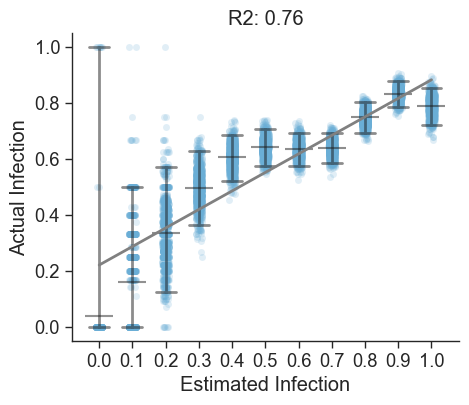

In [91]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.pointplot(
    data=bootstrap_counts,
    x="Estimated Infection",
    y="Actual Infection",
    hue="Estimated Infection",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=bootstrap_counts,
    x="Estimated Infection",
    y="Actual Infection",
    #hue="Label",
    ax=ax,
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

ax.plot(
    predictions["x"],
    predictions["y"],
    lw=2,
    color="gray",
)


ax.set_title(
    f"R2: {rsquared:.2f}"
)

fig.set_size_inches(5, 4)

In [92]:
fig.savefig("infection.pdf", dpi=300, bbox_inches="tight")

In [93]:
combined_results.to_csv(
    "design_matrix_test_infection_risk.tsv",
    sep="\t"
)

# ICU

In [94]:
testing_data['ICU Prob'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column="critical_care",
    bootstrap=True
)

In [95]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [96]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['critical_care'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual ICU": actual_mort,
            "Estimated ICU": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [97]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [98]:
bootstrap_counts.to_csv(
    "icu_df.tsv",
    sep="\t",
    index=False
)

In [99]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated ICU']], bootstrap_counts[['Actual ICU']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated ICU']].values.ravel(), bootstrap_counts[['Actual ICU']].values.ravel())
linregress_results


LinregressResult(slope=1.4450310940406197, intercept=-0.0625105635405434, rvalue=0.8509207772725211, pvalue=0.0, stderr=0.010992074827533269, intercept_stderr=0.0037432317676621613)

In [101]:
rsquared = linregress_results.rvalue ** 2

In [102]:

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts['Estimated ICU'].unique()

In [103]:
predictions = pd.DataFrame(
    {
        "x": bootstrap_counts['Estimated ICU'].unique(),
        "y": predictions
    }
)

In [104]:
predictions = predictions.sort_values("x")

In [105]:
predictions['x'] = predictions['x'].astype("str")

In [106]:
bootstrap_counts['Estimated ICU'] = bootstrap_counts['Estimated ICU'].astype(str)

In [107]:
bootstrap_counts['Estimated ICU'] = bootstrap_counts['Estimated ICU'].str[:3]

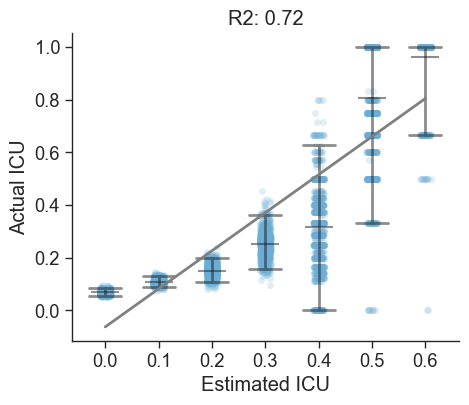

In [108]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.pointplot(
    data=bootstrap_counts,
    x="Estimated ICU",
    y="Actual ICU",
    hue="Estimated ICU",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=bootstrap_counts,
    x="Estimated ICU",
    y="Actual ICU",
    #hue="Label",
    ax=ax,
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

ax.plot(
    predictions["x"],
    predictions["y"],
    lw=2,
    color="gray",
)

ax.set_title(
    f"R2: {rsquared:.2f}"
)

fig.set_size_inches(5, 4)


In [109]:
fig.savefig("icu.pdf", dpi=300, bbox_inches="tight")

In [110]:
combined_results.to_csv(
    "design_matrix_test_infection_icu.tsv",
    sep="\t"
)